In [ ]:
from src.data_loader import get_BESSTIE_splits
from src.eda import EDA, get_sarcasm_extremes,variety_slang

In [ ]:
df_all, df_train, df_val,df_test = get_BESSTIE_splits()

eda = EDA(df_train, df_val, df_test)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

In [ ]:
print("---------SARCASM PATTERNS----------")
sarcasm_patterns, examples = eda.sarcastic_phrases_analysis()

---------SARCASM PATTERNS----------
   'as if': found in 4 sarcastic texts
   'sure': found in 48 sarcastic texts
   'of course': found in 8 sarcastic texts
   'well done': found in 1 sarcastic texts
   'good job': found in 1 sarcastic texts
   'really?': found in 45 sarcastic texts
   'seriously?': found in 11 sarcastic texts
   'obviously': found in 4 sarcastic texts
   'fantastic': found in 3 sarcastic texts


In [ ]:
pos_data, sarc_pos, non_sarc_pos = eda.pos_for_sarcasm()
print("\n")
print("----------PART OF SPEECH ANALYSIS----------")
print(f"{'POS Tag':<12} {'Sarcastic %':<15} {'Non-sarcastic %':<15}")
for pos, sarc_pct, non_pct in zip(pos_data['pos_tags'], pos_data['sarcastic_pcts'], pos_data['non_sarcastic_pcts']):
    print(f"{pos:<12} {sarc_pct:.1f}%{' ':<10} {non_pct:.1f}%")
print("\n")



----------PART OF SPEECH ANALYSIS----------
POS Tag      Sarcastic %     Non-sarcastic %
NOUN         17.4%           18.3%
VERB         11.5%           10.5%
ADJ          7.0%           9.4%
ADV          5.1%           6.4%
INTJ         0.4%           0.2%
PRON         8.8%           8.6%
ADP          8.7%           7.9%




In [ ]:
sarcasm_source_crosstab = eda.sarcasm_by_source()
print(sarcasm_source_crosstab)

Sarcasm   0.0  1.0
source            
Google   3087   55
Reddit   2283  818


In [ ]:
sentiment_source_crosstab = eda.sentiment_by_source()
print(sentiment_source_crosstab)

Sentiment   0.0   1.0
source               
Google      808  2334
Reddit     2376   725


Saved: reports/figures/variety_distribution.png


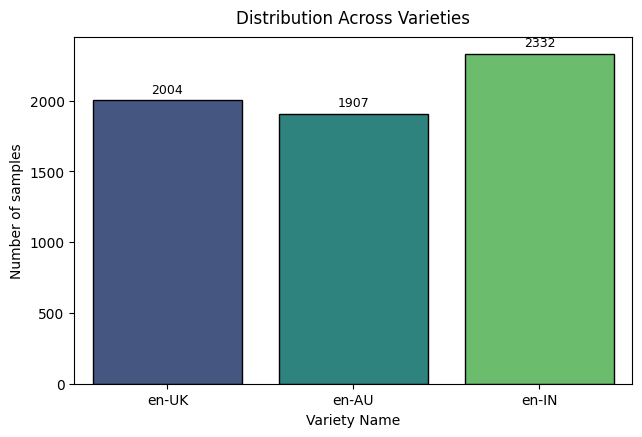

Saved: reports/figures/source_distribution.png


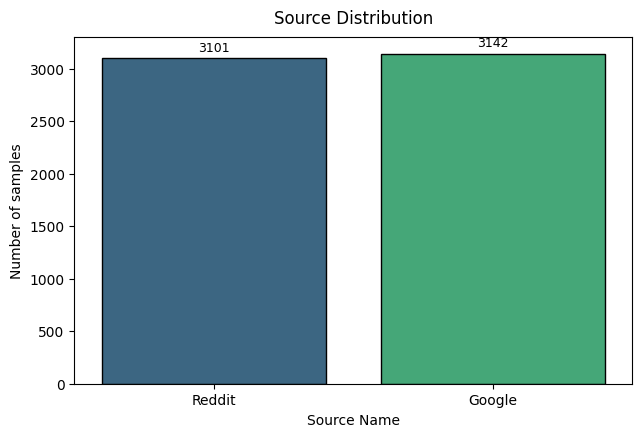

In [14]:
variety_counts, source_counts = eda.variety_source_dist(eda.df_all)

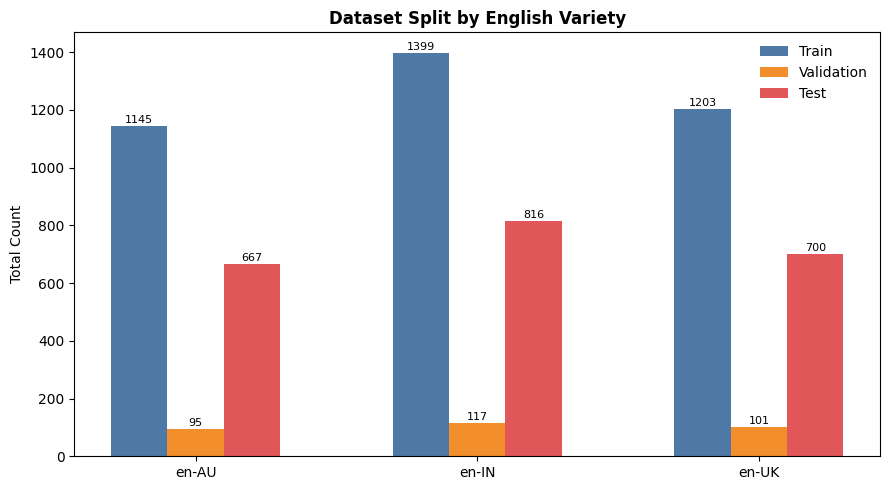

In [15]:
split_distribution = eda.split_distribution_per_variety()

Saved: reports/figures/stacked_variety_by_source.png


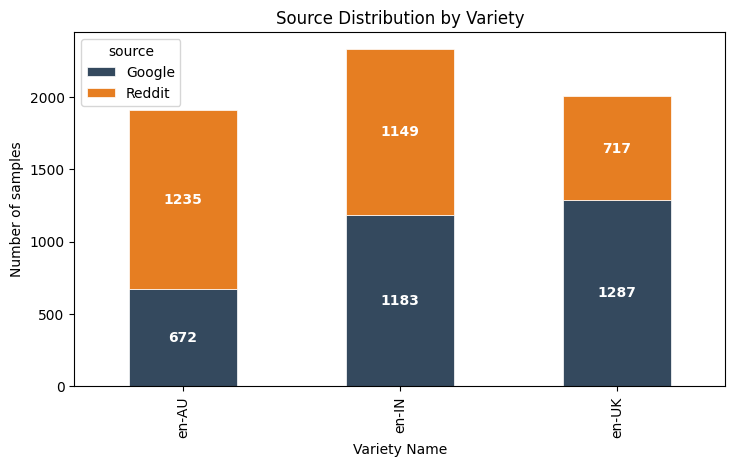

In [16]:
source_variety_crosstab = eda.source_per_variety()

Saved: reports/figures/heatmap_Sarcasm_Sentiment.png


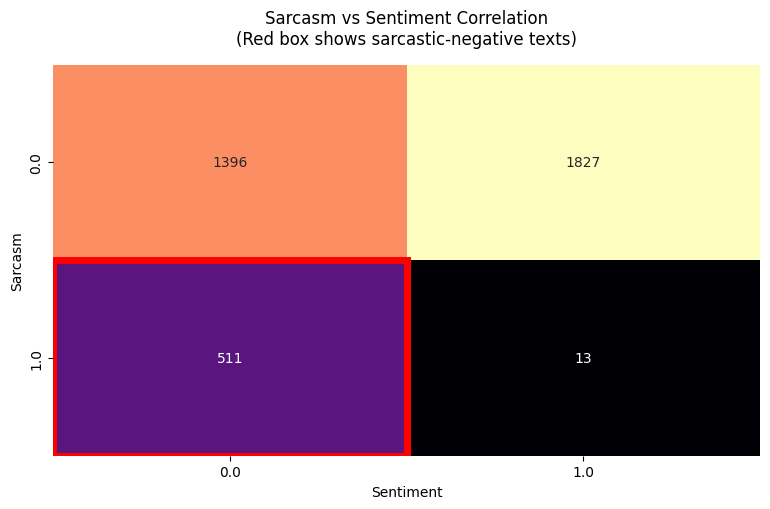

In [17]:
sarcasm_sentiment_crosstab = eda.sarcasm_sentiment_correlation()

Saved: reports/figures/variety_vs_Sarcasm_pct.png


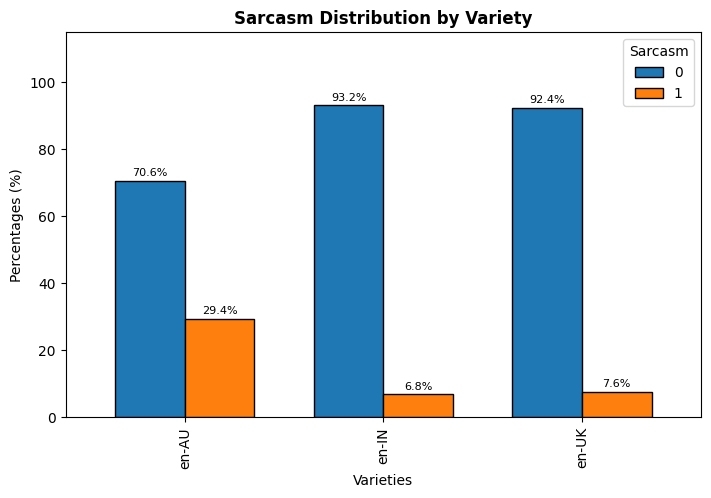

----------OVERALL Sarcasm DISTRIBUTION----------
   Positive (1): 13.98%
   Negative (0): 86.02%
----------Sarcasm BY VARIETY (%)----------
Variety      Positive (1)    Negative (0)   
en-AU        29.42%         70.58%
en-IN        6.82%         93.18%
en-UK        7.63%         92.37%
---------Sarcasm BY VARIETY & SPLIT (%)----------
Variety      Split        Positive (1)    Negative (0)   
en-AU        test         29.39%         70.61%
en-AU        train        29.43%         70.57%
en-AU        validation   29.47%         70.53%
en-IN        test         6.86%         93.14%
en-IN        train        6.79%         93.21%
en-IN        validation   6.84%         93.16%
en-UK        test         7.57%         92.43%
en-UK        train        7.65%         92.35%
en-UK        validation   7.92%         92.08%




In [19]:
overall_sarcasm, per_variety_sarcasm, per_split_sarcasm = eda.sarcasm_imbalance()
print("----------OVERALL Sarcasm DISTRIBUTION----------")
print(f"   Positive (1): {overall_sarcasm[1]:.2f}%")
print(f"   Negative (0): {overall_sarcasm[0]:.2f}%")

print("----------Sarcasm BY VARIETY (%)----------")
print(f"{'Variety':<12} {'Positive (1)':<15} {'Negative (0)':<15}")
for variety in per_variety_sarcasm.index:
    pos_pct = per_variety_sarcasm.loc[variety, 1]
    neg_pct = per_variety_sarcasm.loc[variety, 0]
    print(f"{variety:<12} {pos_pct:.2f}%{' ':<8} {neg_pct:.2f}%")

print("---------Sarcasm BY VARIETY & SPLIT (%)----------")
print(f"{'Variety':<12} {'Split':<12} {'Positive (1)':<15} {'Negative (0)':<15}")

for (variety, split) in per_split_sarcasm.index:
    pos_pct = per_split_sarcasm.loc[(variety, split), 1]
    neg_pct = per_split_sarcasm.loc[(variety, split), 0]
    print(f"{variety:<12} {split:<12} {pos_pct:.2f}%{' ':<8} {neg_pct:.2f}%")

print("\n")

Saved: reports/figures/variety_vs_Sentiment_pct.png


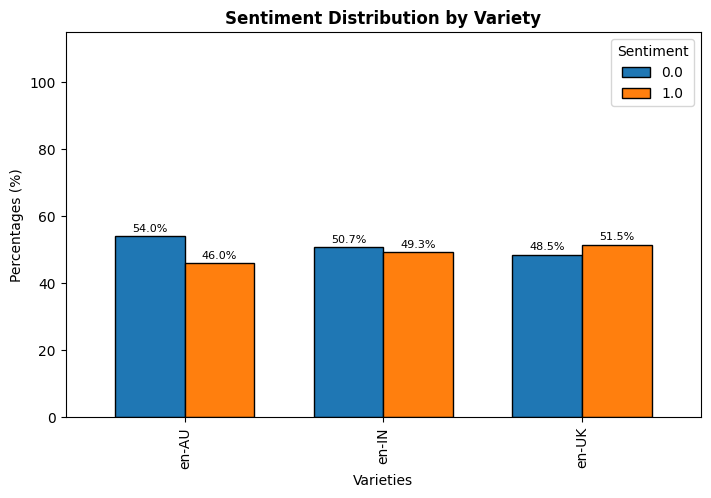

----------OVERALL SENTIMENT DISTRIBUTION----------
   Positive (1): 49.00%
   Negative (0): 51.00%

 ----------SENTIMENT BY VARIETY (%)----------
Variety      Positive (1)    Negative (0)   
en-AU        45.99%         54.01%
en-IN        49.27%         50.73%
en-UK        51.55%         48.45%

 ----------SENTIMENT BY VARIETY & SPLIT (%)----------
Variety      Split        Positive (1)    Negative (0)   
en-AU        test         47.98%         52.02%
en-AU        train        44.72%         55.28%
en-AU        validation   47.37%         52.63%
en-IN        test         47.30%         52.70%
en-IN        train        50.75%         49.25%
en-IN        validation   45.30%         54.70%
en-UK        test         51.43%         48.57%
en-UK        train        51.37%         48.63%
en-UK        validation   54.46%         45.54%




In [20]:
overall_sentiment, per_variety_sentiment, per_split_sentiment = eda.sentiment_imbalance()
print("----------OVERALL SENTIMENT DISTRIBUTION----------")
print(f"   Positive (1): {overall_sentiment[1]:.2f}%")
print(f"   Negative (0): {overall_sentiment[0]:.2f}%")

print("\n ----------SENTIMENT BY VARIETY (%)----------")
print(f"{'Variety':<12} {'Positive (1)':<15} {'Negative (0)':<15}")
for variety in per_variety_sentiment.index:
    pos_pct = per_variety_sentiment.loc[variety, 1]
    neg_pct = per_variety_sentiment.loc[variety, 0]
    print(f"{variety:<12} {pos_pct:.2f}%{' ':<8} {neg_pct:.2f}%")

print("\n ----------SENTIMENT BY VARIETY & SPLIT (%)----------")
print(f"{'Variety':<12} {'Split':<12} {'Positive (1)':<15} {'Negative (0)':<15}")

for (variety, split) in per_split_sentiment.index:
    pos_pct = per_split_sentiment.loc[(variety, split), 1]
    neg_pct = per_split_sentiment.loc[(variety, split), 0]
    print(f"{variety:<12} {split:<12} {pos_pct:.2f}%{' ':<8} {neg_pct:.2f}%")

print("\n")

In [21]:
slang_results = variety_slang(df_all)
print("\n")
print("----------SLANGS IN DATASET PER VARIETY----------")
for variety, slang_found in slang_results.items():
    print(f"\n {variety.upper()}:")
    print(f"   Found {len(slang_found)} slang terms")
    slangs_only = [slang for slang, _ in slang_found]
    if slang_found:
        print("   Slangs:",end='')
        for i in range(0, len(slangs_only), 5):
                    batch = slangs_only[i:i+5]
                    if i == 0:
                        print(", ".join(batch))
                    else:
                        print("           " + ", ".join(batch))

print("\n")



----------SLANGS IN DATASET PER VARIETY----------

 EN-AU:
   Found 16 slang terms
   Slangs:brekkie, servo, maccas, esky, ute
           mate, bogan, thongs, sunnies, ambo
           pollie, tradie, footy, stoked, heaps
           snag

 EN-IN:
   Found 27 slang terms
   Slangs:yaar, na, re, bhai, acha
           accha, chai, arre, kya, thoda
           hai, nahi, bhaiya, didi, tension
           matlab, actually, basically, seriously, generally
           only, itself, too much, very much, kindly
           timepass, chalta hai

 EN-UK:
   Found 28 slang terms
   Slangs:bloody, brilliant, cheers, boot, flat
           mate, gutted, bloke, bird, lad
           lass, chap, missus, innit, proper
           sorted, fancy, quite, queue, loo
           bog, cuppa, pub, owt, canny
           wee, aye, ken




In [22]:
sarcasm_extremes = get_sarcasm_extremes(per_variety_sarcasm)
print("\n")
print("----------SARCASM EXTREMES----------")
print(f"Most sarcastic variety: {sarcasm_extremes['most_sarcastic']} ({sarcasm_extremes['most_sarcastic_pct']:.2f}%)")
print(f"Least sarcastic variety: {sarcasm_extremes['least_sarcastic']} ({sarcasm_extremes['least_sarcastic_pct']:.2f}%)")



----------SARCASM EXTREMES----------
Most sarcastic variety: en-AU (29.42%)
Least sarcastic variety: en-IN (6.82%)
